<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/Health_Care_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df=pd.read_csv("/content/drive/MyDrive/DATASET /healthcare-dataset-stroke-data.csv")

In [ ]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
df.shape

(5110, 12)

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [ ]:
df['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [ ]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col].astype(str))
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,2,1
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,2,1,83.75,NaN,2,0
5106,44873,0,81.0,0,0,1,3,1,125.20,40.0,2,0
5107,19723,0,35.0,0,0,1,3,0,82.99,30.6,2,0
5108,37544,1,51.0,0,0,1,2,0,166.29,25.6,1,0


In [ ]:
from sklearn.impute import SimpleImputer
si= SimpleImputer(strategy='mean')
df[['bmi']]=si.fit_transform(df[['bmi']])

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


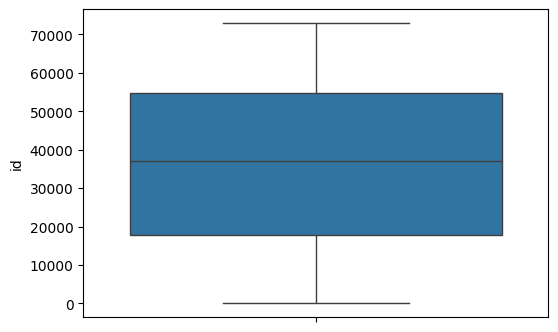

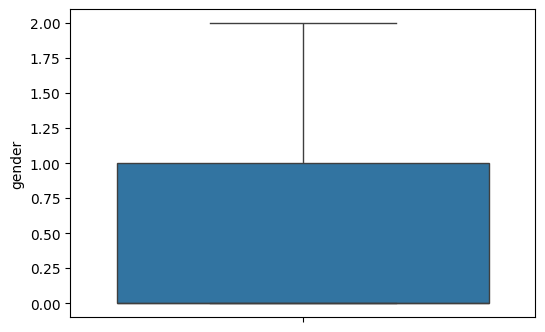

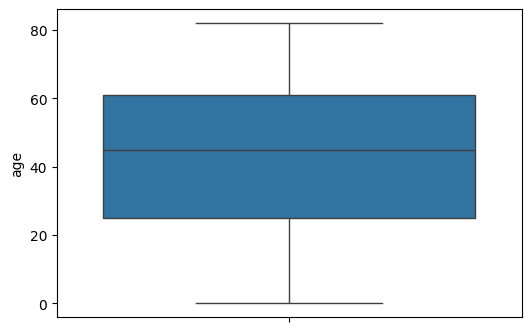

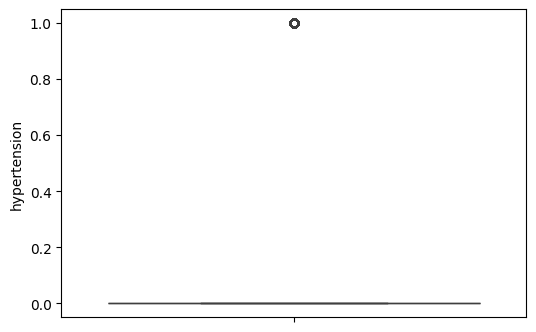

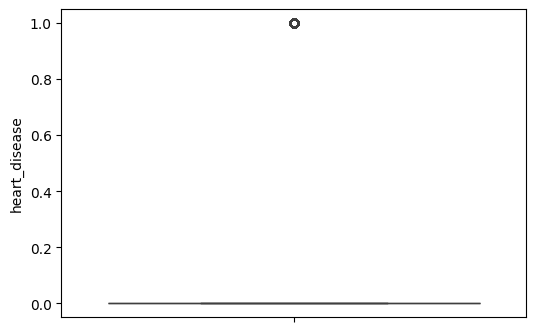

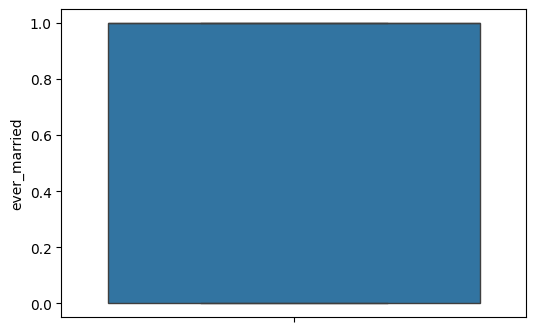

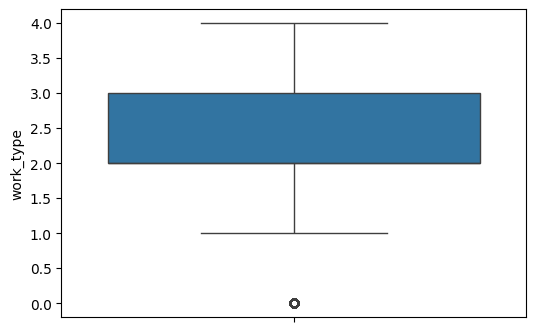

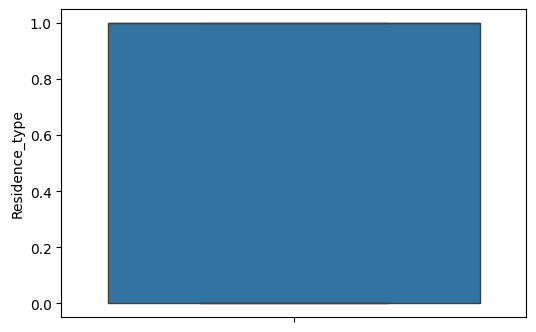

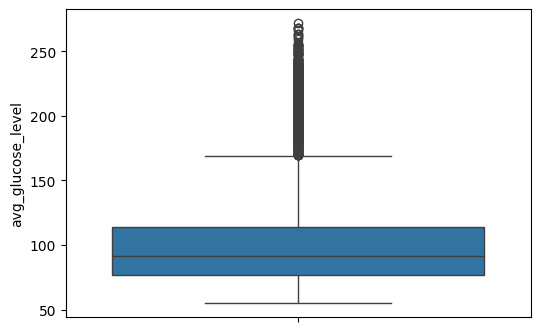

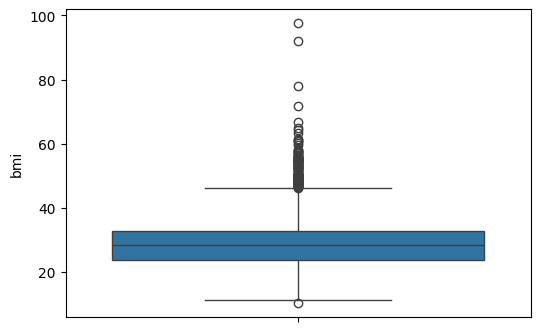

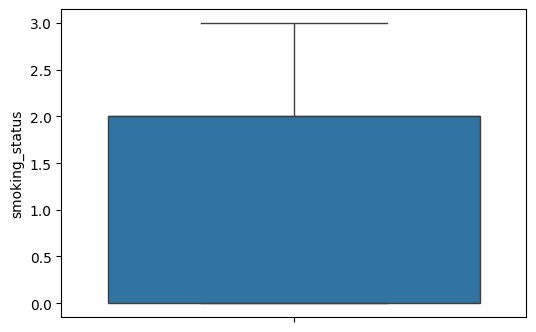

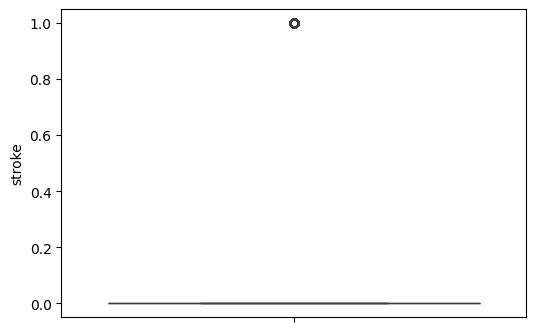

In [ ]:
import seaborn as sns
for col in df.columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])


In [ ]:
from scipy.stats.mstats import winsorize as win
df['bmi']=win(df['bmi'],limits=[0.1,0.1])
df['avg_glucose_level']=win(df['avg_glucose_level'],limits=[0.2,0.2])

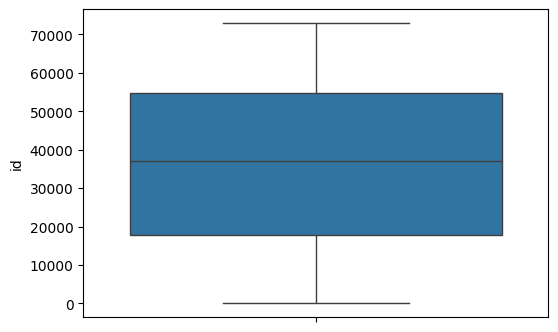

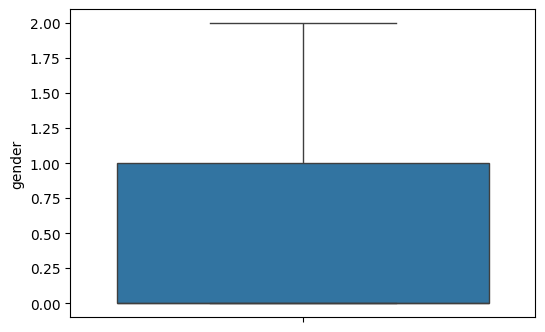

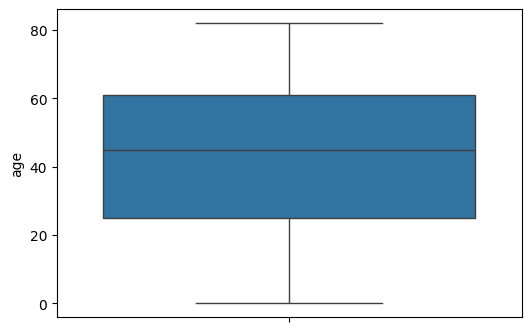

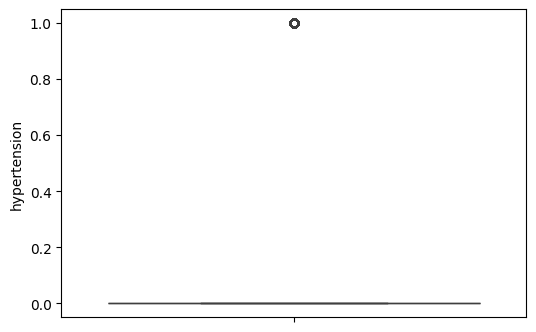

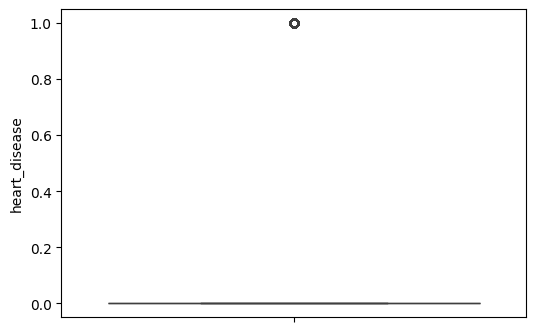

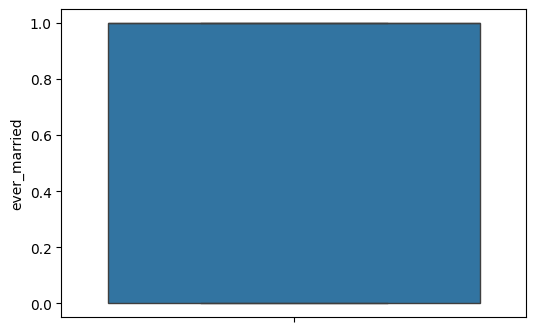

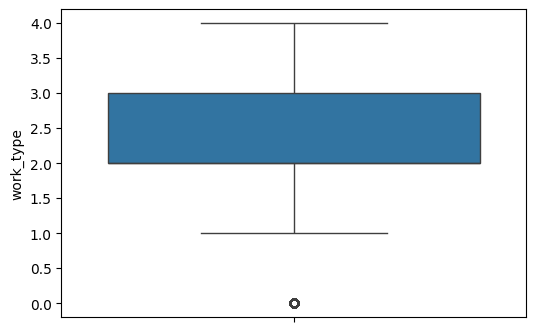

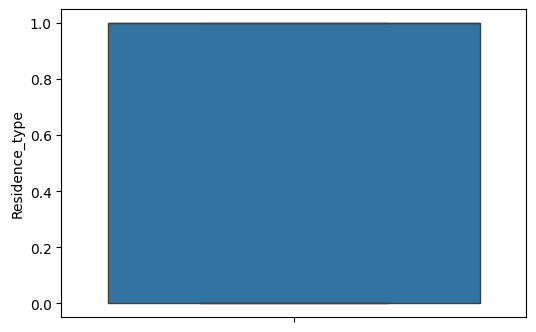

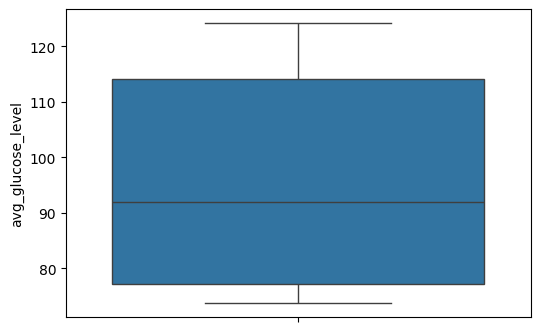

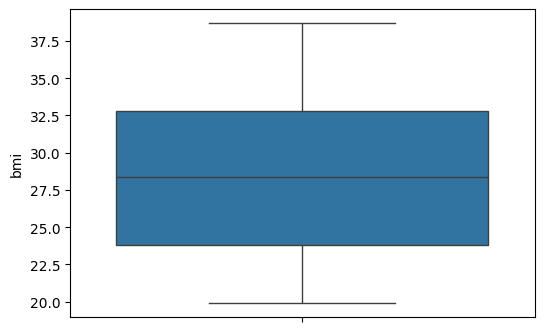

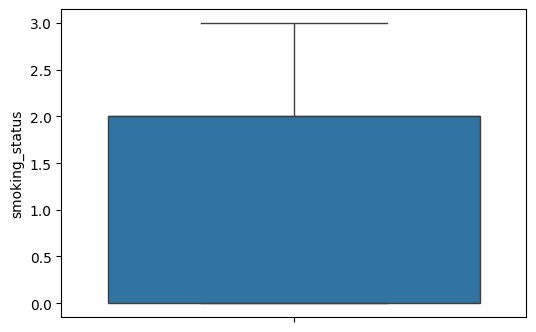

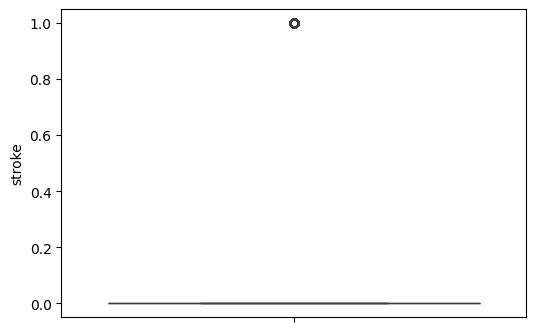

In [ ]:
import seaborn as sns
for col in df.columns:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[col])


In [ ]:
X= df.iloc[:,:-1]
y=df['stroke']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scaled= sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model=keras.Sequential([
     keras.layers.Flatten(input_shape=(11,)),
     keras.layers.Dense(512,activation='relu'),
     keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history=model.fit(X_train_scaled,y_train,validation_split=0.1,epochs=20)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9448 - loss: 0.2306 - val_accuracy: 0.9487 - val_loss: 0.1701
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9546 - loss: 0.1567 - val_accuracy: 0.9487 - val_loss: 0.1622
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9549 - loss: 0.1493 - val_accuracy: 0.9487 - val_loss: 0.1596
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9549 - loss: 0.1465 - val_accuracy: 0.9487 - val_loss: 0.1670
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9554 - loss: 0.1450 - val_accuracy: 0.9487 - val_loss: 0.1658
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9552 - loss: 0.1436 - val_accuracy: 0.9487 - val_loss: 0.1647
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9552 - loss: 0.1430 - val_accuracy: 0.9487 - val_loss: 0.1663
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9549 - loss: 0.1418 - val_accuracy: 0.